--- Model Math ---
Coefficient (Weight): 1.1465
Intercept (Bias):     -5.138

--- Actual vs Predicted ---
Actual results:    [0, 0, 0, 1, 1, 1, 1]
Predicted results: [np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1)]

--- New Prediction ---
If a student studies for 4.5 hours, the probability of passing is 50.53%.
Predicted Class: 1 (0 = Fail, 1 = Pass)


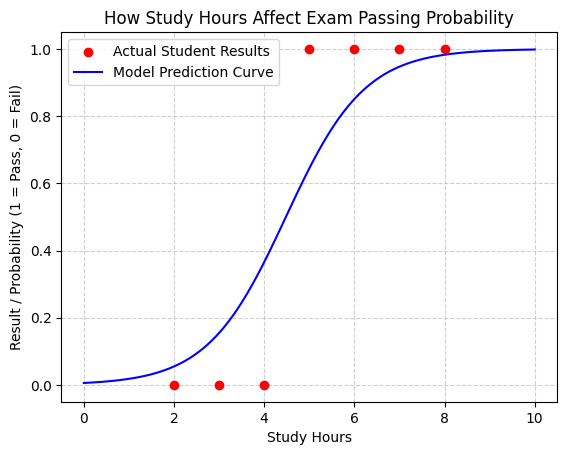

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# 1. Provide the data
# X represents study hours (needs to be a list of lists)
X = [[2], [3], [4], [5], [6], [7], [8]]
# y represents exam results (0 = Fail, 1 = Pass)
y = [0, 0, 0, 1, 1, 1, 1]

# 2. Create and train the model
model = LogisticRegression()
model.fit(X, y)

# 3. Show the math behind the scenes
# Coefficient: How much the chance of passing increases per hour studied
# Intercept: The base probability (represented mathematically) before studying
print("--- Model Math ---")
print("Coefficient (Weight):", round(model.coef_[0][0], 4))
print("Intercept (Bias):    ", round(model.intercept_[0], 4))

# 4. Compare Actual vs Predicted results
predictions = model.predict(X)
print("\n--- Actual vs Predicted ---")
print("Actual results:   ", y)
print("Predicted results:", list(predictions))

# 5. Predict for a new value (e.g., 4.5 hours of study)
test_hours = np.array([[4.5]])
predicted_class = model.predict(test_hours)[0]
predicted_prob = model.predict_proba(test_hours)[0][1] # Probability of passing (class 1)
print(f"\n--- New Prediction ---")
print(f"If a student studies for 4.5 hours, the probability of passing is {predicted_prob*100:.2f}%.")
print(f"Predicted Class: {predicted_class} (0 = Fail, 1 = Pass)")

# 6. Graph the results!
# Create a smooth line from 0 to 10 hours to show the probability curve
x_curve = np.linspace(0, 10, 100).reshape(-1, 1)
y_probability = model.predict_proba(x_curve)[:, 1]

# Plot the actual dots
plt.scatter(X, y, color='red', label='Actual Student Results', zorder=5)

# Plot the "S-Curve" line drawn by our model
plt.plot(x_curve, y_probability, color='blue', label='Model Prediction Curve')

plt.title('How Study Hours Affect Exam Passing Probability')
plt.xlabel('Study Hours')
plt.ylabel('Result / Probability (1 = Pass, 0 = Fail)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()